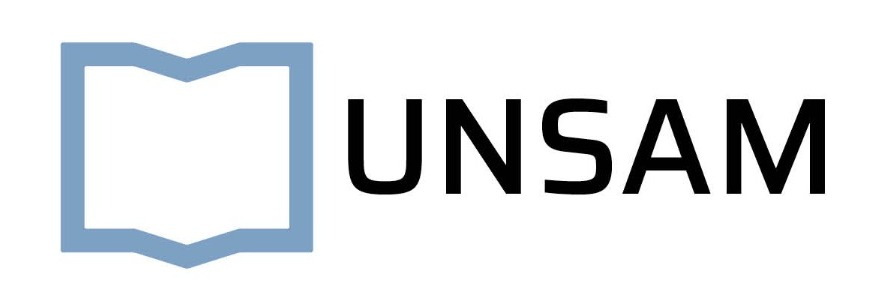

#### Análisis y Procesamiento de Señales

# TS5: Estimación de la densidad espectral de potencia y ancho de banda
#### Alumno: Sebastián Roca Garza



## Introducción
El presente informe tiene como objetivo principal estudiar el contenido frecuencial de diversas señales mediante la estimación de su **Densidad Espectral de Potencia (PSD)**. El análisis en el dominio de la frecuencia es una herramienta fundamental en el Procesamiento Digital de Señales, ya que permite observar características, periodicidades y la distribución de la energía que no son tan evidentes en el dominio temporal.

Para este trabajo, se analizarán tres tipos de señales muy distintas:

*   **Electrocardiograma (ECG):** Registro de la actividad eléctrica del corazón. 
*   **Pletismografía (PPG):** Señal óptica que refleja los cambios de volumen sanguíneo en la microvascularización.
*   **Audio:** Señales acústicas capturadas mediante un micrófono.

### Metodología y Elección de la Ventana

Dado que se trata de señales reales, la estimación de la PSD se realizará utilizando **métodos no paramétricos**. Específicamente:

1.  **Periodograma Ventaneado:** Se obtendrá una estimación inicial aplicando una ventana matemática a la totalidad del registro.
2.  **Método de Welch:** Se dividirá la señal en segmentos solapados, calculando el periodograma modificado de cada uno y promediándolos. Esto permitirá analizar de forma práctica el compromiso fundamental que existe en la estimación espectral: la reducción de la **varianza** del estimador a costa de una pérdida en la **resolución frecuencial**.

Para la aplicación de ambos métodos, es crucial la elección de la ventana matemática para mitigar el efecto de la **fuga espectral** (*spectral leakage*). En este trabajo se optó por utilizar la ventana de **Hann** ya que presenta una buena relación entre la resolución frecuencial (ancho del lóbulo principal, lo que permite distinguir frecuencias cercanas) y la atenuación de los lóbulos laterales. 

Particularmente para el método de Welch, la ventana de Hann resulta ideal: al utilizar un solapamiento (*overlap*) del 50% entre los segmentos temporales, la suma de las ventanas da como resultado una constante. Esto garantiza que ninguna porción de la señal original quede atenuada o subrepresentada de forma asimétrica en el promedio espectral final.

Finalmente, a partir de las densidades espectrales estimadas, se calculará el **ancho de banda efectivo** para cada una de las señales. Los resultados se presentarán en una tabla comparativa, lo que permitirá relacionar la naturaleza física del fenómeno generador (biológico vs. acústico) con su ocupación espectral y las frecuencias de muestreo utilizadas para su registro.

# Codigo y Análisis


## Cargo las señales

In [16]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write


#%%

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
#io.whosmat('ECG_TP4.mat')
#mat_struct = sio.loadmat('./ECG_TP4.mat')

#ecg_one_lead = mat_struct['ecg_lead']
# N = len(ecg_one_lead)

# hb_1 = mat_struct['heartbeat_pattern1']
# hb_2 = mat_struct['heartbeat_pattern2']

#plt.figure()
# plt.plot(ecg_one_lead[5000:12000])

# plt.figure()
# plt.plot(hb_1)

# plt.figure()
# plt.plot(hb_2)

##################
## ECG sin ruido
##################

ecg_one_lead = np.load('ecg_sin_ruido.npy')

#plt.figure()
#plt.plot(ecg_one_lead)


#%%

####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG con ruido
##################

# # Cargar el archivo CSV como un array de NumPy
# ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)  # Omitir la cabecera si existe


##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

#plt.figure()
#plt.plot(ppg)


#%%

####################
# Lectura de audio #
####################

# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
# fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('silbido.wav')

#plt.figure()
#plt.plot(wav_data)

# si quieren oirlo, tienen que tener el siguiente módulo instalado
# pip install sounddevice
# import sounddevice as sd
# sd.play(wav_data, fs_audio)

## Análisis de la Señal de Audio

En esta sección, analizaremos la señal acústica. En primer lugar, calcularemos la Densidad Espectral de Potencia mediante el Periodograma estándar. Luego, aplicaremos el método de Welch variando la cantidad de promedios ($K$) para observar empíricamente el compromiso entre la varianza del estimador y la resolución frecuencial. Finalmente, estimaremos el ancho de banda calculando la frecuencia por debajo de la cual se concentra el 99% de la potencia total de la señal.

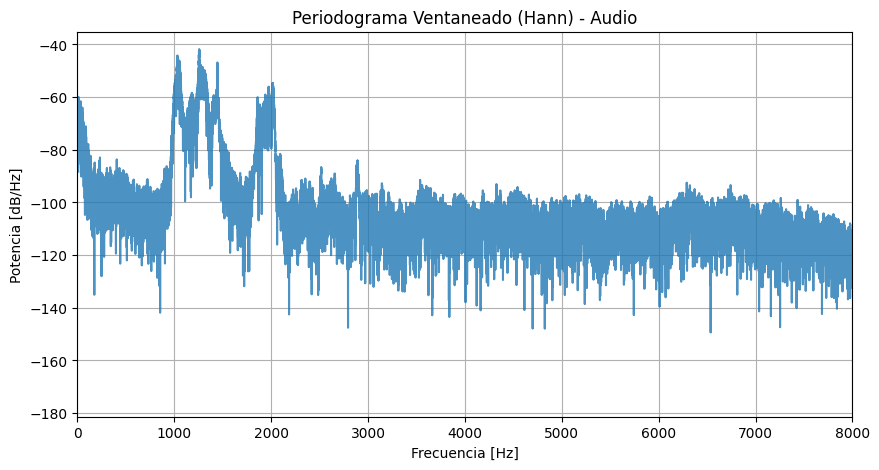

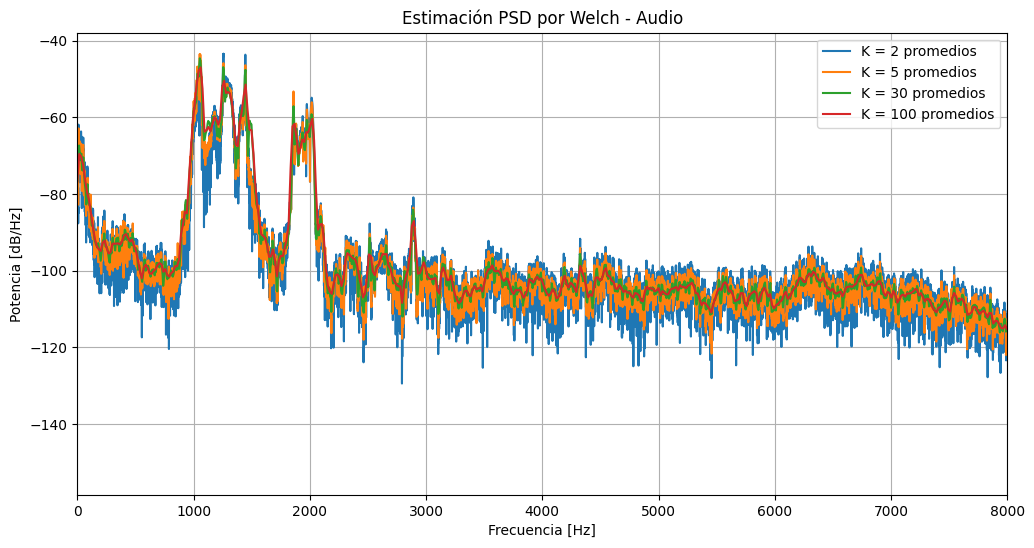

--> Ancho de banda estimado para Audio (K=30, 99% de energía): 2009.90 Hz


In [17]:
# ANÁLISIS DE LA SEÑAL DE AUDIO


# PERIODOGRAMA
frec_audio_per, pot_audio_per = sig.periodogram(wav_data, fs_audio, window='hann')
pot_audio_per_db = 10 * np.log10(pot_audio_per)

plt.figure(figsize=(10,5))
plt.plot(frec_audio_per, pot_audio_per_db, color='C0', alpha=0.8)
plt.title('Periodograma Ventaneado (Hann) - Audio')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 8000) 
plt.grid(True)
plt.show()

# WELCH
L_audio = len(wav_data)
cant_prom = [2, 5, 30, 100]

plt.figure(figsize=(12,6))

# Variables para guardar el mejor Welch y calcular el ancho de banda
frec_audio_welch = None
pot_audio_welch = None

for K in cant_prom:
    nperseg = int(2 * L_audio / (K + 1))
    frec, pot = sig.welch(wav_data, fs_audio, window='hann', nperseg=nperseg)
    pot_db = 10 * np.log10(pot)
    plt.plot(frec, pot_db, label=f"K = {K} promedios")
    
    # Guarda datos de K=30 para calcular el ancho de banda
    if K == 30:
        frec_audio_welch = frec
        pot_audio_welch = pot

plt.title('Estimación PSD por Welch - Audio')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 8000)
plt.legend()
plt.grid(True)
plt.show()

# CÁLCULO DEL ANCHO DE BANDA (Criterio del 99% de la potencia total)
pot_acumulada_audio = np.cumsum(pot_audio_welch)
pot_total_audio = pot_acumulada_audio[-1]
indice_99_audio = np.where(pot_acumulada_audio >= 0.99 * pot_total_audio)[0][0]
bw_audio = frec_audio_welch[indice_99_audio]

print(f"--> Ancho de banda estimado para Audio (K=30, 99% de energía): {bw_audio:.2f} Hz")

**Análisis de los resultados (Audio):**

Al observar el **Periodograma**, se hace evidente que es un estimador con una varianza muy alta (la gráfica se percibe muy "ruidosa" y con picos erráticos). Al aplicar el **método de Welch**, observamos el compromiso fundamental entre varianza y resolución:
* Con pocos promedios ($K=2$ o $K=5$), la curva sigue siendo ruidosa, pero conserva una gran resolución frecuencial 
* Al aumentar excesivamente los promedios ($K=100$), la varianza disminuye drásticamente, pero el tamaño de la ventana temporal (`nperseg`) se vuelve tan pequeño que la resolución frecuencial se degrada, ensanchando los picos.
* Un valor intermedio (ej. $K=30$) ofrece un excelente equilibrio.

El ancho de banda calculado demuestra que la mayor parte de la información acústica se concentra en los primeros miles de Hertz

## Análisis de la Señal de ECG 

A continuación, procesaremos el registro de electrocardiografía. Al tratarse de una señal fisiológica de origen cardíaco, esperamos encontrar su contenido espectral principal en frecuencias significativamente más bajas que las de la señal acústica. Aplicaremos la misma metodología empleada anteriormente para caracterizar su espectro y estimar su ancho de banda efectivo.

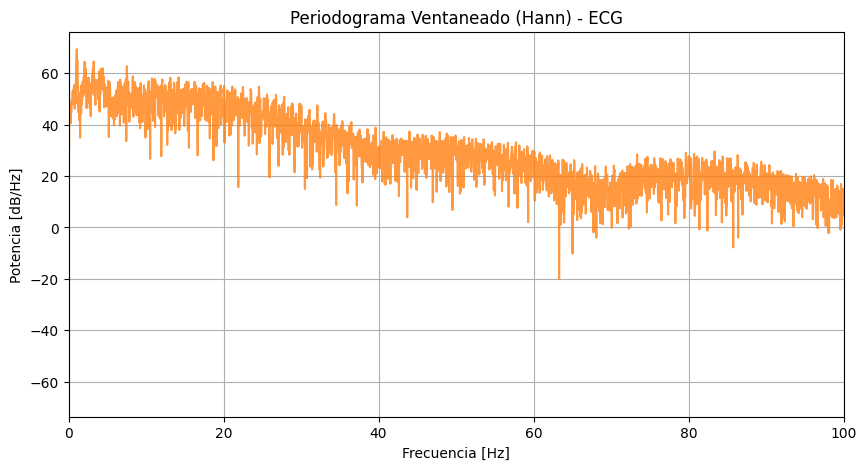

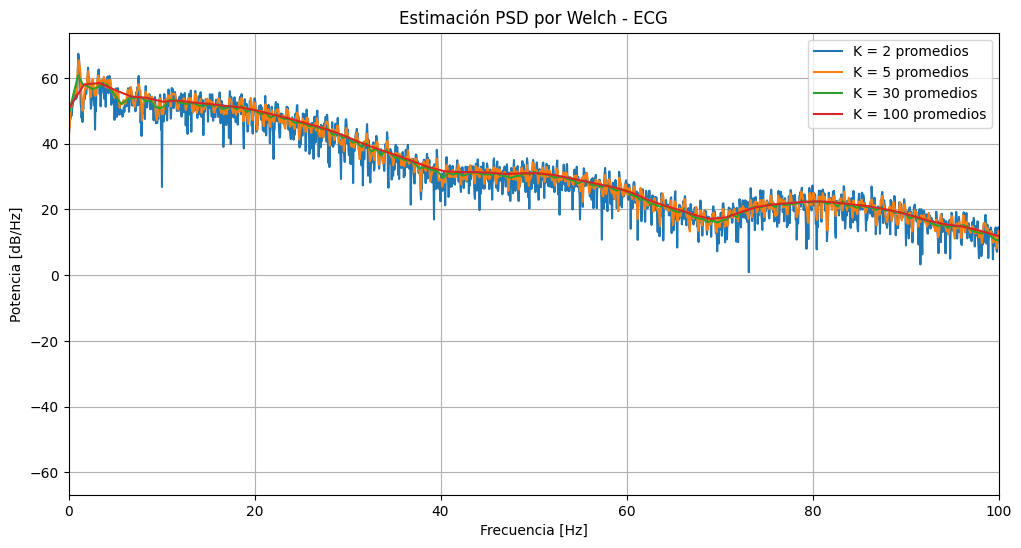

--> Ancho de banda estimado para ECG (K=30, 99% de energía): 31.52 Hz


In [18]:
# ANÁLISIS DE LA SEÑAL DE ECG


# PERIODOGRAMA
frec_ecg_per, pot_ecg_per = sig.periodogram(ecg_one_lead, fs_ecg, window='hann')
pot_ecg_per_db = 10 * np.log10(pot_ecg_per)

plt.figure(figsize=(10,5))
plt.plot(frec_ecg_per, pot_ecg_per_db, color='C1', alpha=0.8)
plt.title('Periodograma Ventaneado (Hann) - ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 100) 
plt.grid(True)
plt.show()

# WELCH
L_ecg = len(ecg_one_lead)
plt.figure(figsize=(12,6))

frec_ecg_welch = None
pot_ecg_welch = None

for K in cant_prom:
    nperseg = int(2 * L_ecg / (K + 1))
    frec, pot = sig.welch(ecg_one_lead, fs_ecg, window='hann', nperseg=nperseg)
    pot_db = 10 * np.log10(pot)
    plt.plot(frec, pot_db, label=f"K = {K} promedios")
    
    if K == 30:
        frec_ecg_welch = frec
        pot_ecg_welch = pot

plt.title('Estimación PSD por Welch - ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

# CÁLCULO DEL ANCHO DE BANDA
pot_acumulada_ecg = np.cumsum(pot_ecg_welch)
pot_total_ecg = pot_acumulada_ecg[-1]
indice_99_ecg = np.where(pot_acumulada_ecg >= 0.99 * pot_total_ecg)[0][0]
bw_ecg = frec_ecg_welch[indice_99_ecg]

print(f"--> Ancho de banda estimado para ECG (K=30, 99% de energía): {bw_ecg:.2f} Hz")

**Análisis de los resultados (ECG):**

A diferencia del audio, el ECG es una señal biológica de **baja frecuencia**. La mayor parte de la información reside cerca de la banda base.

El método de Welch logra suavizar la estimación espectral, permitiendo observar claramente cómo la potencia cae de forma abrupta a medida que superamos los 40 Hz. 

El cálculo del ancho de banda (criterio del 99% de la energía) confirma la naturaleza lenta de esta señal, ubicándose su contenido útil de información muy por debajo de la frecuencia de Nyquist ($fs/2 = 500$ Hz) disponible por su frecuencia de muestreo.

## Análisis de la Señal de PPG

Por último, analizaremos la señal de pletismografía (PPG), que refleja los cambios de volumen sanguíneo en la microvascularización. Dado que es una señal de dinámica extremadamente lenta, prestaremos especial atención a la elección del número de promedios ($K$) en el método de Welch para evitar degradar la resolución en las frecuencias ultrabajas.

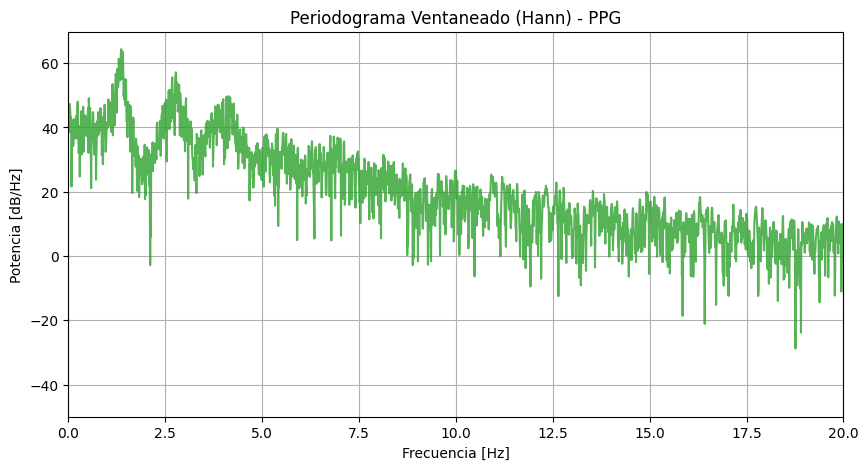

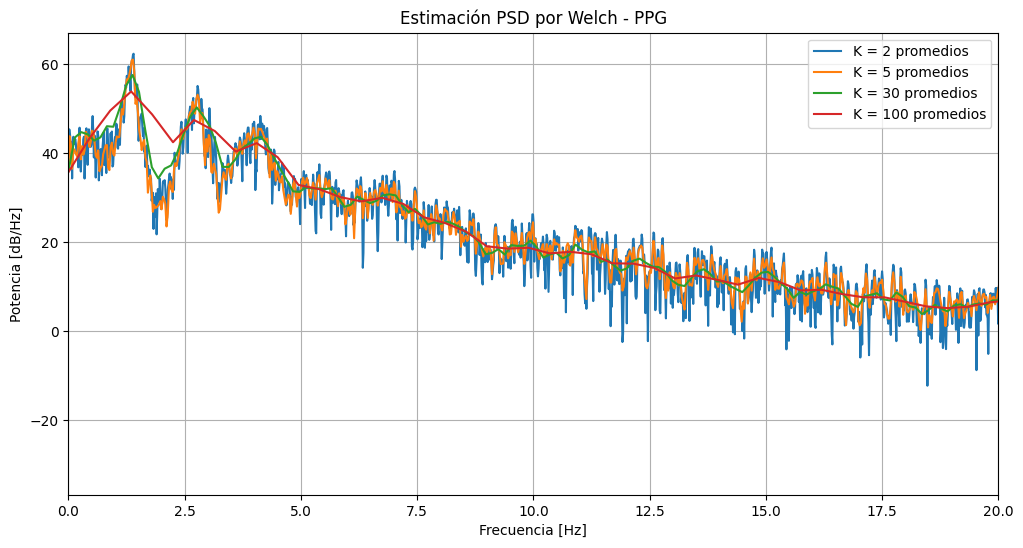

--> Ancho de banda estimado para PPG (K=5, 99% de energía): 5.72 Hz


In [19]:
# 3. ANÁLISIS DE LA SEÑAL DE PPG


# PERIODOGRAMA
frec_ppg_per, pot_ppg_per = sig.periodogram(ppg, fs_ppg, window='hann')
pot_ppg_per_db = 10 * np.log10(pot_ppg_per)

plt.figure(figsize=(10,5))
plt.plot(frec_ppg_per, pot_ppg_per_db, color='C2', alpha=0.8)
plt.title('Periodograma Ventaneado (Hann) - PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 20) # El PPG es extremadamente lento
plt.grid(True)
plt.show()

# WELCH
L_ppg = len(ppg)
plt.figure(figsize=(12,6))

frec_ppg_welch = None
pot_ppg_welch = None

for K in cant_prom:
    nperseg = int(2 * L_ppg / (K + 1))
    frec, pot = sig.welch(ppg, fs_ppg, window='hann', nperseg=nperseg)
    pot_db = 10 * np.log10(pot)
    plt.plot(frec, pot_db, label=f"K = {K} promedios")
    
    if K == 5: # Para PPG (muy lenta), un K muy alto arruina la resolución en bajas frec. Uso K=5.
        frec_ppg_welch = frec
        pot_ppg_welch = pot

plt.title('Estimación PSD por Welch - PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB/Hz]')
plt.xlim(0, 20)
plt.legend()
plt.grid(True)
plt.show()

# CÁLCULO DEL ANCHO DE BANDA
pot_acumulada_ppg = np.cumsum(pot_ppg_welch)
pot_total_ppg = pot_acumulada_ppg[-1]
indice_99_ppg = np.where(pot_acumulada_ppg >= 0.99 * pot_total_ppg)[0][0]
bw_ppg = frec_ppg_welch[indice_99_ppg]

print(f"--> Ancho de banda estimado para PPG (K=5, 99% de energía): {bw_ppg:.2f} Hz")

**Análisis de los resultados (PPG):**

De las tres señales analizadas, el PPG es **la de dinámica más lenta**. Prácticamente la totalidad de la energía espectral se encuentra concentrada por debajo de los 5-10 Hz, con un pico fundamental que suele ubicarse entre 1 Hz y 2 Hz.

**Consideración sobre la partición temporal ($K$):**
A diferencia de las señales anteriores, para calcular el ancho de banda del PPG se utilizó un valor de promediación menor ($K=5$). Si dividimos este registro en demasiados segmentos, las ventanas temporales resultantes (`nperseg`) son tan cortas que no llegan a contener suficientes ciclos completos de la señal. Esto empastaría las bajas frecuencias, perdiendo la capacidad de distinguir el pico fundamental del ritmo cardíaco.

# Conclusión


El presente trabajo práctico permitio comprobar empíricamente las ventajas del método de Welch frente al Periodograma tradicional para la estimación de la Densidad Espectral de Potencia (PSD) en procesos estocásticos del mundo real, evidenciando visual y cuantitativamente el compromiso que existe entre la reducción de la varianza estadística del estimador y la preservación de una resolución frecuencial acorde. La aplicación de este marco analítico sobre tres señales de distinta naturaleza dejó al descubierto las marcadas diferencias en sus anchos de banda, contrastando la amplia ocupación espectral y alta frecuencia de las señales acústicas frente a la pronunciada concentración de energía en las bandas base típica de las señales biológicas cardiovasculares (ECG y PPG). En definitiva, los resultados demuestran que no existe una parametrización algorítmica universal; la correcta configuración del procesamiento, como la adopción de una ventana de Hann y el delicado ajuste en la cantidad de promedios ($K$), debe realizarse siempre desde un profundo entendimiento de la dinámica temporal del fenómeno físico a analizar, garantizando así la correcta extracción de la información sin distorsionar ni enmascarar las componentes fundamentales de cada sistema.